# What is Linear regression? And its Type.

### 📘 What is Linear Regression?

**Linear Regression** is a **supervised machine learning algorithm** used to **predict a continuous value** (like price, salary, marks, temperature) based on one or more input variables.

It finds a **straight-line relationship** between:

* **Independent variable(s)** → input (X)
* **Dependent variable** → output (Y)

#### 🔹 Basic idea:

> “How does Y change when X changes?”

#### 🔹 Simple equation:

[
y = mx + c
]
Where:

* **y** = predicted value
* **x** = input feature
* **m** = slope (how much y changes when x increases)
* **c** = intercept (value of y when x = 0)

---

### 📊 Example:

Predicting **house price** based on **house size**

* X = size (sq ft)
* Y = price

---

## 🔑 Types of Linear Regression

### 1️⃣ Simple Linear Regression

* Uses **only one independent variable**
* Formula:
  [
  y = mx + c
  ]

**Example:**
Salary based on **years of experience**

---

### 2️⃣ Multiple Linear Regression

* Uses **more than one independent variable**
* Formula:
  [
  y = b_0 + b_1x_1 + b_2x_2 + ... + b_nx_n
  ]

**Example:**
House price based on:

* size
* number of rooms
* location

---

### 3️⃣ Polynomial Linear Regression

* Relationship is **not straight**, but **curved**
* Still called linear because it is linear in coefficients
* Formula:
  [
  y = b_0 + b_1x + b_2x^2 + b_3x^3
  ]

**Example:**
Car speed vs fuel consumption

---

### 4️⃣ Ridge Regression

* Type of **regularized linear regression**
* Used when data has **multicollinearity**
* Adds penalty to large coefficients (L2)

**Purpose:** Prevents overfitting

---

### 5️⃣ Lasso Regression

* Also a **regularized linear regression**
* Uses **L1 penalty**
* Can make some coefficients **zero**

**Purpose:** Feature selection

---

### 6️⃣ Elastic Net Regression

* Combination of **Ridge + Lasso**
* Uses both **L1 and L2 penalties**

---

## 📌 Summary Table

| Type            | Features Used | Purpose               |
| --------------- | ------------- | --------------------- |
| Simple Linear   | 1             | Basic prediction      |
| Multiple Linear | 2 or more     | Real-world problems   |
| Polynomial      | Powers of X   | Non-linear data       |
| Ridge           | Multiple      | Reduce overfitting    |
| Lasso           | Multiple      | Feature selection     |
| Elastic Net     | Multiple      | Best of Ridge + Lasso |

---

### ✅ When to use Linear Regression?

* Output is **continuous**
* Relationship is **linear**
* Data has **low noise**




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Advertising Budget and Sales.csv")

In [ ]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [ ]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.rename(columns={"TV Ad Budget ($)":"Tv",	"Radio Ad Budget ($)":"Radio",	"Newspaper Ad Budget ($)":"Newspaper",	"Sales ($)":"Sales"},inplace=True)

In [ ]:
df.head()

,Unnamed: 0,Tv,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
df.head()

,Tv,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


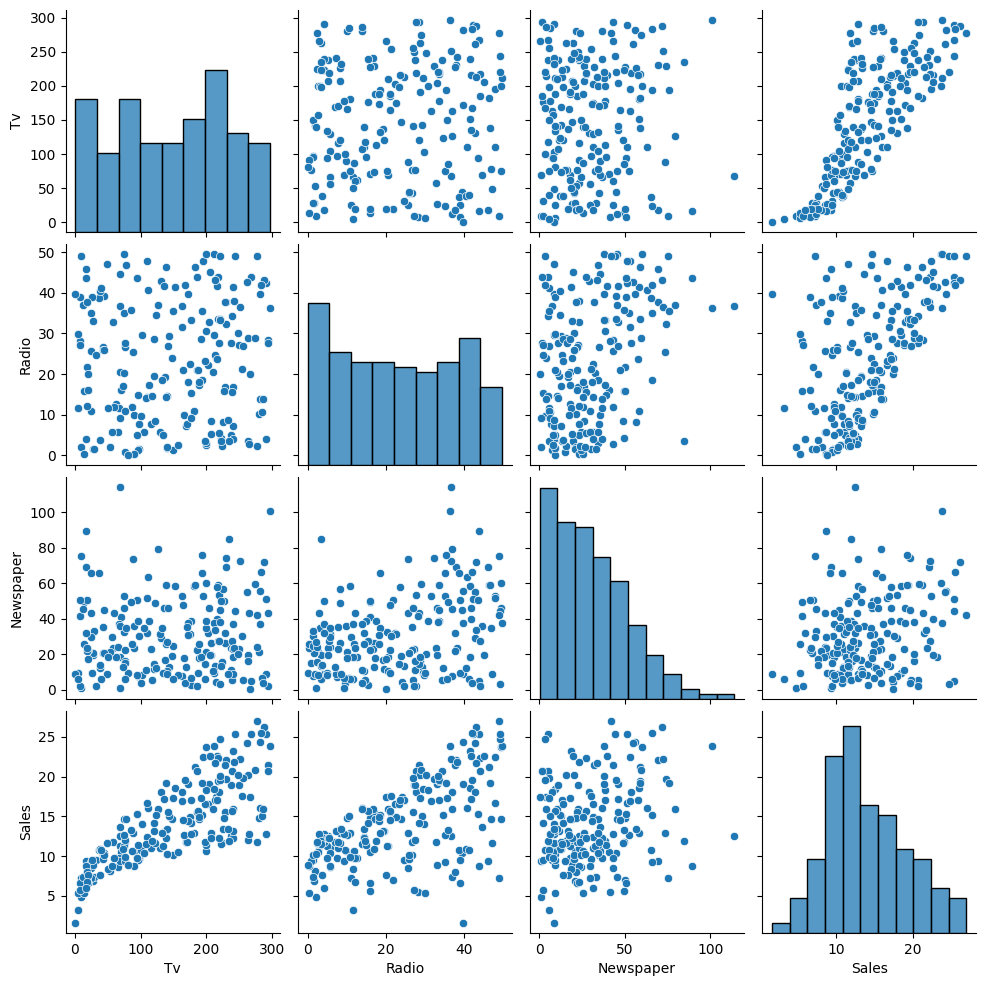

In [ ]:
sns.pairplot(df)
plt.show()

<Axes: >

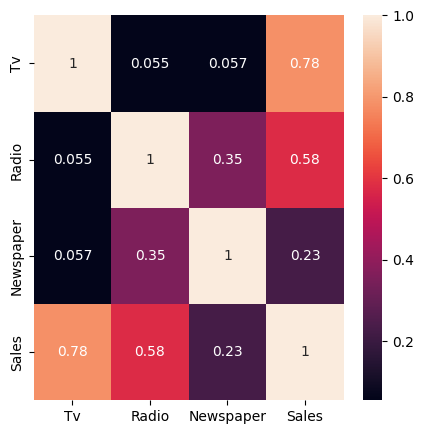

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(),annot=True)

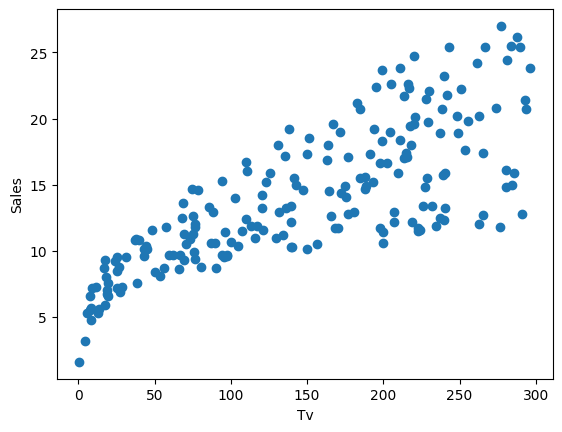

In [ ]:
plt.scatter(df['Tv'],df['Sales'])
plt.xlabel("Tv")
plt.ylabel("Sales")
plt.show()

In [ ]:
x=df['Tv']
y=df['Sales']


In [ ]:
x.shape

(200,)

In [ ]:
x=x.values.reshape(200,1)
x.shape

(200, 1)

In [ ]:
y.shape

(200,)

In [ ]:
y=y.values.reshape(200,1)
y.shape

(200, 1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [ ]:
x_train

array([[116. ],
       [177. ],
       [ 43.1],
       [ 62.3],
       [224. ],
       [ 38.2],
       [ 70.6],
       [147.3],
       [104.6],
       [ 76.3],
       [ 78.2],
       [168.4],
       [  8.7],
       [  7.8],
       [ 76.4],
       [129.4],
       [ 73.4],
       [289.7],
       [ 19.6],
       [197.6],
       [284.3],
       [184.9],
       [112.9],
       [ 23.8],
       [290.7],
       [ 19.4],
       [293.6],
       [ 18.7],
       [134.3],
       [ 25.6],
       [100.4],
       [ 80.2],
       [188.4],
       [177. ],
       [125.7],
       [209.6],
       [142.9],
       [184.9],
       [222.4],
       [241.7],
       [ 17.2],
       [120.5],
       [ 89.7],
       [191.1],
       [ 75.5],
       [193.2],
       [ 85.7],
       [266.9],
       [ 39.5],
       [261.3],
       [ 13.2],
       [193.7],
       [296.4],
       [265.6],
       [214.7],
       [149.7],
       [131.7],
       [ 57.5],
       [240.1],
       [141.3],
       [180.8],
       [ 97.2],
       [

In [ ]:
lr=LinearRegression()


# Simple Linear regession

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(x_test)
y_pred

array([[14.71794394],
       [16.2115484 ],
       [20.74819743],
       [ 7.66403631],
       [17.37013877],
       [10.61402143],
       [17.2072847 ],
       [ 9.44612512],
       [17.46785121],
       [15.2669948 ],
       [ 8.58532504],
       [ 9.73460946],
       [18.03086098],
       [ 7.37089899],
       [13.61053628],
       [15.03899911],
       [ 7.45930549],
       [16.31391381],
       [10.62332738],
       [18.16579721],
       [17.79821232],
       [10.27435438],
       [ 8.88776831],
       [18.79394862],
       [10.33019006],
       [ 9.60897918],
       [17.05373658],
       [13.60123034],
       [11.17703121],
       [ 7.51048819],
       [16.41627922],
       [10.339496  ],
       [16.37440246],
       [ 7.90599093],
       [20.18053468],
       [18.203021  ],
       [ 9.36702457],
       [19.85482655],
       [12.57292322],
       [ 8.39920611]])

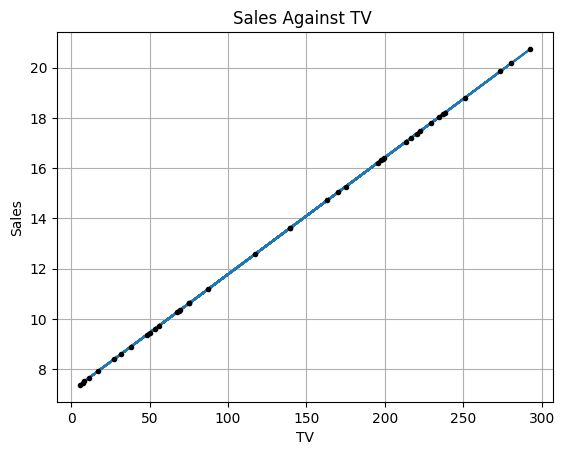

In [ ]:
plt.figure()
plt.title('Sales Against TV ')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.plot(x_test,y_pred)
plt.plot(x_test,y_pred,'k.')
plt.grid()
plt.show()


In [ ]:
for i,predictions in enumerate(y_pred):
  print('actual Price: %s and Predicted Price: %s' %(y_test[i],predictions))

actual Price: [16.9] and Predicted Price: [14.71794394]
actual Price: [22.4] and Predicted Price: [16.2115484]
actual Price: [21.4] and Predicted Price: [20.74819743]
actual Price: [7.3] and Predicted Price: [7.66403631]
actual Price: [24.7] and Predicted Price: [17.37013877]
actual Price: [12.6] and Predicted Price: [10.61402143]
actual Price: [22.3] and Predicted Price: [17.2072847]
actual Price: [8.4] and Predicted Price: [9.44612512]
actual Price: [11.5] and Predicted Price: [17.46785121]
actual Price: [14.9] and Predicted Price: [15.2669948]
actual Price: [9.5] and Predicted Price: [8.58532504]
actual Price: [8.7] and Predicted Price: [9.73460946]
actual Price: [11.9] and Predicted Price: [18.03086098]
actual Price: [5.3] and Predicted Price: [7.37089899]
actual Price: [10.3] and Predicted Price: [13.61053628]
actual Price: [11.7] and Predicted Price: [15.03899911]
actual Price: [5.5] and Predicted Price: [7.45930549]
actual Price: [16.6] and Predicted Price: [16.31391381]
actual 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# y_test = actual values
# y_pred = model predictions

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rsme=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MAE",mae)
print("MSE",mse)
print("RSME",rsme)
print("R2_Score",r2)

MAE 2.444420003751042
MSE 10.204654118800956
RSME 3.194472431998898
R2_Score 0.6766954295627076


# Multi Linear regession

In [ ]:
x=df.drop('Sales',axis=1)
y=df['Sales']

In [ ]:
x

,Tv,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [ ]:
y


,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pre=lr.predict(x_test)
y_pre

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [ ]:
for i,prediction in enumerate(y_pre):
  print('actual Price: %s and Predicted Price: %s' %(y_test.iloc[i],prediction))

actual Price: 16.9 and Predicted Price: 16.408024203228628
actual Price: 22.4 and Predicted Price: 20.889882087147885
actual Price: 21.4 and Predicted Price: 21.553843179089558
actual Price: 7.3 and Predicted Price: 10.6085025619849
actual Price: 24.7 and Predicted Price: 22.112373259857662
actual Price: 12.6 and Predicted Price: 13.105591724016454
actual Price: 22.3 and Predicted Price: 21.057191916314647
actual Price: 8.4 and Predicted Price: 7.461010344558369
actual Price: 11.5 and Predicted Price: 13.60634580543393
actual Price: 14.9 and Predicted Price: 15.155069668921398
actual Price: 9.5 and Predicted Price: 9.048319924103865
actual Price: 8.7 and Predicted Price: 6.653283124939039
actual Price: 11.9 and Predicted Price: 14.345544865081424
actual Price: 5.3 and Predicted Price: 8.903493328870406
actual Price: 10.3 and Predicted Price: 9.689590280381115
actual Price: 11.7 and Predicted Price: 12.16494385914241
actual Price: 5.5 and Predicted Price: 8.736283973362841
actual Price:

In [ ]:
# y_test = actual values
# y_pre = model predictions

mae=mean_absolute_error(y_test,y_pre)
mse=mean_squared_error(y_test,y_pre)
rsme=np.sqrt(mse)
r2=r2_score(y_test,y_pre)

print("MAE",mae)
print("MSE",mse)
print("RSME",rsme)
print("R2_Score",r2)

MAE 1.4607567168117603
MSE 3.1740973539761033
RSME 1.78159966153345
R2_Score 0.899438024100912


# Polynomial regession

In [ ]:
poly_feature=PolynomialFeatures(degree=2)

In [ ]:
x_train=poly_feature.fit_transform(x_train)
x_test=poly_feature.fit_transform(x_test)

In [ ]:
pr=LinearRegression()

In [ ]:
pr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=pr.predict(x_test)
y_pred

array([17.25443578, 22.7193321 , 20.42799436,  7.542709  , 24.37103037,
       12.55927164, 22.80784986,  8.34371358, 12.0586023 , 15.69024565,
        7.89166367,  8.27082715, 11.86055971,  6.16591094, 10.57664393,
       12.3628954 ,  6.74390963, 16.65082111, 10.68661722, 19.03888161,
       20.15223945, 13.1137814 ,  9.56273868, 22.10675225,  8.96725241,
        7.7794437 , 22.40745151, 12.72065973, 10.25529986,  6.22368636,
       11.64677688, 10.22431946, 23.39763949,  9.17403232, 15.36143449,
       21.05675814, 10.9795286 , 20.23370753, 11.85153256,  6.58779915])

In [ ]:
for i,predictions in enumerate(y_pred):
  print('actual Price: %s and Predicted Price: %s' %(y_test.iloc[i],predictions))

actual Price: 16.9 and Predicted Price: 17.25443578421151
actual Price: 22.4 and Predicted Price: 22.719332098787888
actual Price: 21.4 and Predicted Price: 20.4279943599341
actual Price: 7.3 and Predicted Price: 7.542708996441649
actual Price: 24.7 and Predicted Price: 24.371030368769677
actual Price: 12.6 and Predicted Price: 12.559271635604164
actual Price: 22.3 and Predicted Price: 22.807849861474054
actual Price: 8.4 and Predicted Price: 8.343713576679239
actual Price: 11.5 and Predicted Price: 12.058602302533435
actual Price: 14.9 and Predicted Price: 15.690245648360365
actual Price: 9.5 and Predicted Price: 7.891663667904025
actual Price: 8.7 and Predicted Price: 8.270827153870238
actual Price: 11.9 and Predicted Price: 11.860559712580104
actual Price: 5.3 and Predicted Price: 6.165910943379144
actual Price: 10.3 and Predicted Price: 10.576643926736509
actual Price: 11.7 and Predicted Price: 12.362895400851478
actual Price: 5.5 and Predicted Price: 6.743909627103889
actual Price

In [ ]:
# y_test = actual values
# y_pred = model predictions

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rsme=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MAE",mae)
print("MSE",mse)
print("RSME",rsme)
print("R2_Score",r2)

MAE 0.5261794444043838
MSE 0.41291022853790765
RSME 0.6425809120553673
R2_Score 0.9869181490609602
